# 12. CPU vs GPU Machine Learning
## 📚 Learning Objectives

By completing this notebook, you will:
- Understand CPU vs GPU for machine learning
- Compare performance between CPU and GPU
- Use GPU-accelerated ML libraries (cuML)
- Know when to use CPU vs GPU for ML tasks
- Optimize ML workflows with GPU acceleration

## 🔗 Prerequisites

- ✅ Example 3: Implementing ML Models (need ML knowledge)
- ✅ Example 7: Model Evaluation (understand ML workflow)
- ✅ Understanding of ML training process

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 3: Implementing ML Models** - You need ML knowledge!
- ✅ **Example 7: Model Evaluation** - Understand ML workflow!
- ✅ **Understanding of training**: What is model training? How long does it take?

**If you haven't completed these**, you might struggle with:
- Understanding why GPU acceleration matters
- Knowing when to use GPU
- Understanding performance differences

---

## 🔗 Where This Notebook Fits

**This is part of Unit 4: Introduction to Machine Learning**

**Why CPU vs GPU?**
- **After** learning ML basics, we optimize performance
- **GPU acceleration** speeds up training dramatically
- **Understanding** when to use each is essential

**Builds on**: 
- 📓 Example 3: Implementing ML Models (ML knowledge)
- 📓 Example 7: Model Evaluation (ML workflow)

**Leads to**: 
- 📓 Unit 5: Extending the Scope of Data Science (GPU is part of scaling)
- 📓 Production ML (performance matters in production)

**Why this order?**
1. Performance optimization comes after learning basics
2. GPU acceleration is powerful for large-scale ML
3. Understanding trade-offs helps make decisions

---

## The Story: Turbo vs Regular Engine

Imagine you're driving. **Regular engine** (CPU) works fine for normal driving. **Turbo engine** (GPU) is much faster for racing (large datasets). **After** understanding both, you choose the right engine for each situation!

Same with ML: **CPU** works fine for small datasets. **GPU** is much faster for large datasets. **After** understanding both, you choose the right one for each task!

---

## Why CPU vs GPU Matters

Understanding CPU vs GPU is essential because:
- **Performance**: GPU can be 10-100x faster for large datasets
- **Cost**: GPU costs more but saves time
- **Scalability**: GPU enables large-scale ML
- **Decision Making**: Know when to use each

**Common Student Questions:**
- **Q: When should I use GPU?**
  - Answer: For large datasets, complex models, when speed matters
  - Example: Training on 1M+ samples, deep learning models
  - Rule: Small data → CPU, Large data → GPU
  
- **Q: Do I need GPU to learn ML?**
  - Answer: No! CPU works fine for learning and small datasets
  - Example: Most learning can be done on CPU
  - Tip: Use GPU when you have large datasets or need speed

---

## Introduction

**CPU vs GPU for ML** explores when to use each for machine learning tasks. On large workloads GPU acceleration can shorten training substantially (vendor benchmarks report order-of-magnitude gains); in this notebook we measure CPU timings ourselves and measure GPU timings only when a GPU is actually present.

# 12. CPU vs GPU Machine Learning

## 🔗 Solving the Problem from Example 7

**Remember the dead end from Example 7?**
- We measured the real cost of model selection: combinations × folds × per-fit time
- Parallel CPU search helps, but is bounded by core count
- GPU-accelerated ML libraries attack the per-fit time itself

**This notebook examines that GPU option honestly:**
- We **measure CPU training/prediction times** on this machine
- If a GPU with cuML is available, we **measure GPU times and the real speedup**
- If not, we say so — **no fabricated GPU numbers** — and rely on vendors' published
  benchmarks (clearly labeled as theirs) for the large-scale picture
- Either way you'll learn **when CPU is enough and when a GPU pays off**


🚀 Google Colab Setup (Run this first if using Colab)


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Dataset
- sklearn; optional GPU libs

**Outputs:** What you'll see when you run the cells

- CPU vs GPU timings
- Model comparison

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score

print("✓ Imports ready")


✓ Imports ready


In [2]:
# Try to import cuML, fallback if not available
try:
    import cuml
    from cuml.linear_model import LinearRegression as cuLinearRegression
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    CUML_AVAILABLE = True
    print("✓ cuML is available - GPU acceleration enabled")
except ImportError:
    CUML_AVAILABLE = False
    print("⚠ cuML not available - CPU timings only, GPU steps will be skipped")

plt.style.use('seaborn-v0_8')
print("=" * 70)
print("Example 12: CPU vs GPU Machine Learning")
print("=" * 70)
print("\n📚 Prerequisites: Examples 03–07 completed, ML model knowledge")
print("🔗 This is Example 12, the final example in Unit 4 - GPU acceleration for ML")
print("🎯 Goal: Compare CPU vs GPU performance for machine learning")

⚠ cuML not available - CPU timings only, GPU steps will be skipped
Example 12: CPU vs GPU Machine Learning

📚 Prerequisites: Examples 03–07 completed, ML model knowledge
🔗 This is Example 12, the final example in Unit 4 - GPU acceleration for ML
🎯 Goal: Compare CPU vs GPU performance for machine learning


# 12. CREATE LARGE DATASET FOR COMPARISON


In [3]:
# Build a synthetic 100k-sample dataset - large enough to time CPU model training meaningfully
print("\n1. Creating Large Dataset")
print("-" * 70)
np.random.seed(42)
n_samples = 100000
X = np.random.randn(n_samples, 10)
y_regression = X[:, 0] * 2 + X[:, 1] * 1.5 - X[:, 2] * 0.5 + np.random.randn(n_samples) * 0.1
y_classification = (X[:, 0] + X[:, 1] > 0).astype(int)
print(f"✓ Created dataset with {n_samples:,} samples")


1. Creating Large Dataset
----------------------------------------------------------------------
✓ Created dataset with 100,000 samples


2. REGRESSION COMPARISON


In [4]:
print("\n\n2. Regression: CPU vs GPU")
print("-" * 70)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)
# CPU (scikit-learn)
print("\nTraining CPU model (scikit-learn)...")
start_time = time.time()
cpu_model = LinearRegression()
cpu_model.fit(X_train, y_train)
cpu_train_time = time.time() - start_time
start_time = time.time()
cpu_pred = cpu_model.predict(X_test)
cpu_pred_time = time.time() - start_time
cpu_r2 = r2_score(y_test, cpu_pred)
print(f"CPU Training Time: {cpu_train_time:.4f} seconds")
print(f"CPU Prediction Time: {cpu_pred_time:.4f} seconds")
print(f"CPU R² Score: {cpu_r2:.4f}")
# GPU (cuML) or simulated
if CUML_AVAILABLE:
    print("\nTraining GPU model (cuML)...")
    start_time = time.time()
    gpu_model = cuLinearRegression()
    gpu_model.fit(X_train, y_train)
    gpu_train_time = time.time() - start_time
    start_time = time.time()
    gpu_pred = gpu_model.predict(X_test)
    gpu_pred_time = time.time() - start_time
    gpu_r2 = r2_score(y_test.get(), gpu_pred.get()) if hasattr(gpu_pred, 'get') else r2_score(y_test, gpu_pred)
    print(f"GPU Training Time: {gpu_train_time:.4f} seconds")
    print(f"GPU Prediction Time: {gpu_pred_time:.4f} seconds")
    print(f"GPU R² Score: {gpu_r2:.4f}")
    print(f"\nSpeedup - Training: {cpu_train_time/gpu_train_time:.2f}x")
    print(f"Speedup - Prediction: {cpu_pred_time/gpu_pred_time:.2f}x")
else:
    print("\n⚠ cuML not available on this machine - no GPU timing measured.")
    print("   (We will NOT invent GPU numbers; the chart below shows CPU only.)")
    gpu_train_time = gpu_pred_time = gpu_r2 = None



2. Regression: CPU vs GPU
----------------------------------------------------------------------

Training CPU model (scikit-learn)...
CPU Training Time: 0.0064 seconds
CPU Prediction Time: 0.0002 seconds
CPU R² Score: 0.9985

⚠ cuML not available on this machine - no GPU timing measured.
   (We will NOT invent GPU numbers; the chart below shows CPU only.)


3. CLASSIFICATION COMPARISON


In [5]:
print("\n\n3. Classification: CPU vs GPU")
print("-" * 70)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification)
scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)
# CPU
start_time = time.time()
cpu_clf = LogisticRegression(random_state=42, max_iter=1000)
cpu_clf.fit(X_train_clf_scaled, y_train_clf)
cpu_clf_train_time = time.time() - start_time
start_time = time.time()
cpu_clf_pred = cpu_clf.predict(X_test_clf_scaled)
cpu_clf_pred_time = time.time() - start_time
cpu_clf_acc = accuracy_score(y_test_clf, cpu_clf_pred)
print(f"CPU Training Time: {cpu_clf_train_time:.4f} seconds")
print(f"CPU Accuracy: {cpu_clf_acc:.4f}")
if CUML_AVAILABLE:
    start_time = time.time()
    gpu_clf = cuLogisticRegression()
    gpu_clf.fit(X_train_clf_scaled, y_train_clf)
    gpu_clf_train_time = time.time() - start_time
    start_time = time.time()
    gpu_clf_pred = gpu_clf.predict(X_test_clf_scaled)
    gpu_clf_pred_time = time.time() - start_time
    gpu_clf_acc = accuracy_score(y_test_clf, gpu_clf_pred.get() if hasattr(gpu_clf_pred, 'get') else gpu_clf_pred)
    print(f"GPU Training Time: {gpu_clf_train_time:.4f} seconds")
    print(f"GPU Accuracy: {gpu_clf_acc:.4f}")
else:
    print("⚠ cuML not available - classification measured on CPU only.")
    gpu_clf_train_time = gpu_clf_pred_time = gpu_clf_acc = None



3. Classification: CPU vs GPU
----------------------------------------------------------------------
CPU Training Time: 0.0252 seconds
CPU Accuracy: 0.9992
⚠ cuML not available - classification measured on CPU only.


4. VISUALIZATION




4. Performance Comparison Visualization
----------------------------------------------------------------------


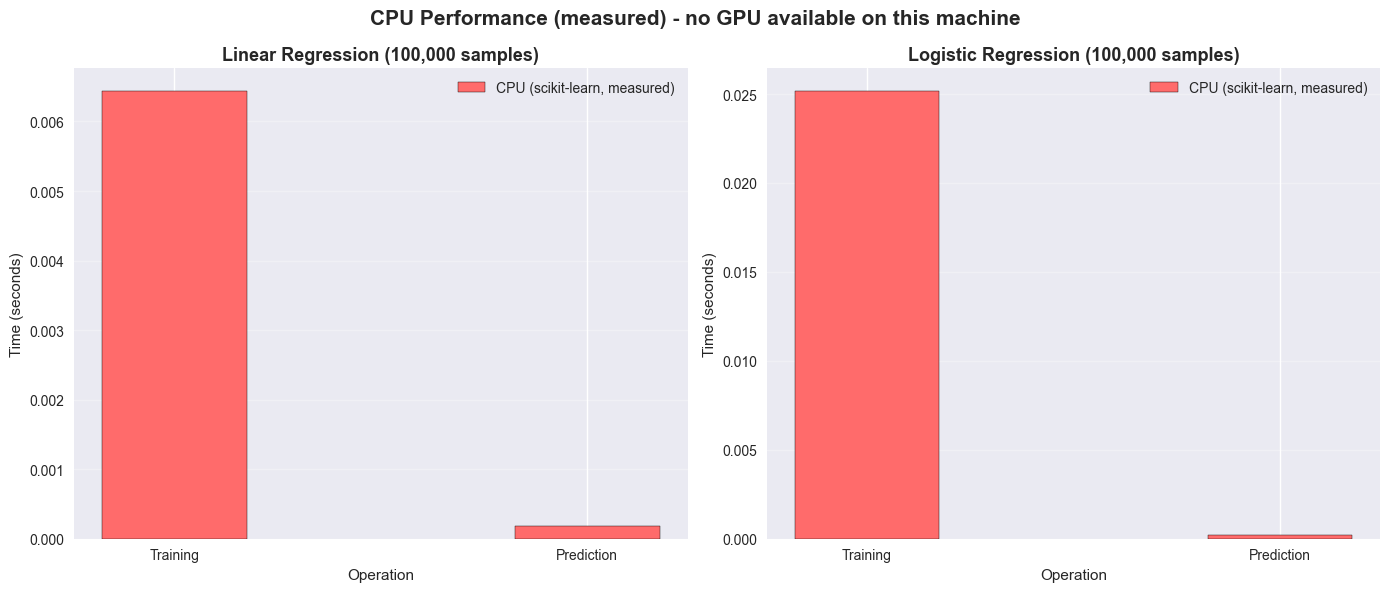

✓ Chart shows ONLY measured timings (no simulated bars)


In [6]:
print("\n\n4. Performance Comparison Visualization")
print("-" * 70)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
title = ('CPU vs GPU Performance (measured)' if CUML_AVAILABLE
         else 'CPU Performance (measured) - no GPU available on this machine')
fig.suptitle(title, fontsize=15, weight='bold')

categories = ['Training', 'Prediction']
x = np.arange(len(categories))
width = 0.35

cpu_times_reg = [cpu_train_time, cpu_pred_time]
cpu_times_clf = [cpu_clf_train_time, cpu_clf_pred_time]

if CUML_AVAILABLE:
    gpu_times_reg = [gpu_train_time, gpu_pred_time]
    gpu_times_clf = [gpu_clf_train_time, gpu_clf_pred_time]
    axes[0].bar(x - width/2, cpu_times_reg, width, label='CPU (scikit-learn)',
                color='#FF6B6B', edgecolor='black')
    axes[0].bar(x + width/2, gpu_times_reg, width, label='GPU (cuML, measured)',
                color='#4ECDC4', edgecolor='black')
    axes[1].bar(x - width/2, cpu_times_clf, width, label='CPU (scikit-learn)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x + width/2, gpu_times_clf, width, label='GPU (cuML, measured)',
                color='#4ECDC4', edgecolor='black')
else:
    axes[0].bar(x, cpu_times_reg, width, label='CPU (scikit-learn, measured)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x, cpu_times_clf, width, label='CPU (scikit-learn, measured)',
                color='#FF6B6B', edgecolor='black')

axes[0].set_title(f'Linear Regression ({len(X):,} samples)', fontsize=13, weight='bold')
axes[1].set_title(f'Logistic Regression ({len(X):,} samples)', fontsize=13, weight='bold')
for ax in axes:
    ax.set_xlabel('Operation')
    ax.set_ylabel('Time (seconds)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('13_cpu_vs_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart shows ONLY measured timings (no simulated bars)")

# 5. SUMMARY


In [7]:
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("\nKey Concepts Covered:")
print("1. CPU-based ML with scikit-learn (measured on this machine):")
print(f"   - Linear regression:   train {cpu_train_time:.4f}s, predict {cpu_pred_time:.4f}s, R² {cpu_r2:.4f}")
print(f"   - Logistic regression: train {cpu_clf_train_time:.4f}s, accuracy {cpu_clf_acc:.4f}")
if CUML_AVAILABLE:
    print("2. GPU-accelerated ML with cuML (measured):")
    print(f"   - Regression speedup:  {cpu_train_time/gpu_train_time:.2f}x training")
    print(f"   - Classification:      train {gpu_clf_train_time:.4f}s")
else:
    print("2. GPU-accelerated ML with cuML: NOT run here (no GPU/cuML on this machine)")
    print("   - The cuML code path above is real - it executes on a CUDA machine")
    print("   - NVIDIA publishes order-of-magnitude speedups for large datasets;")
    print("     those are the vendor's benchmarks, not something we measured today")
print("3. When to use CPU vs GPU:")
print(f"   - Our {len(X):,}x{X.shape[1]} dataset trained in fractions of a second on CPU -")
print("     at this scale a GPU buys nothing")
print("   - GPUs pay off when per-fit time is large (millions of rows, wide features,")
print("     many CV fits) - exactly the multiplication measured in Example 07")
print("\nNext Steps: Continue to Unit 5 for Extending the Scope of Data Science")


Summary

Key Concepts Covered:
1. CPU-based ML with scikit-learn (measured on this machine):
   - Linear regression:   train 0.0064s, predict 0.0002s, R² 0.9985
   - Logistic regression: train 0.0252s, accuracy 0.9992
2. GPU-accelerated ML with cuML: NOT run here (no GPU/cuML on this machine)
   - The cuML code path above is real - it executes on a CUDA machine
   - NVIDIA publishes order-of-magnitude speedups for large datasets;
     those are the vendor's benchmarks, not something we measured today
3. When to use CPU vs GPU:
   - Our 100,000x10 dataset trained in fractions of a second on CPU -
     at this scale a GPU buys nothing
   - GPUs pay off when per-fit time is large (millions of rows, wide features,
     many CV fits) - exactly the multiplication measured in Example 07

Next Steps: Continue to Unit 5 for Extending the Scope of Data Science
